In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations

In [2]:
df = pd.read_csv('../DATA/02_image_clusters/full_image_data_feb_25.csv')
books = pd.read_csv('../DATA/01_corpus_metadata/full_book_data_feb_25.csv')

In [3]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [4]:
# Define the target cks values
target_cks = [
# 'CK_Meridian',
'CK_Horizon',
# 'CK_Elevation of the Pole'
]

In [5]:
#filtering the df to get the images of the target cks with all their data + printing counts
#(this is why only filter is not enough: we need all the cks that are in other rows with double images values)

# Step 1: Filter the DataFrame for rows where 'cks' is in the target_cks list
filtered_df_target_cks = df[df['cks'].isin(target_cks)]

# Step 2: Get the unique 'images' values associated with the target cks
images_with_target_cks = filtered_df_target_cks['images'].unique()

# Step 3: Filter the original DataFrame to include all rows that have these images
filtered_df = df[df['images'].isin(images_with_target_cks)]

# filtered_df

In [6]:
unique_counts = pd.concat([
    df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('df'),
    filtered_df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('filtered_df')
], axis=1)

print(unique_counts)

                 df  filtered_df
images        20540          557
cluster_name   3563           38
cks             168           10
place            42           32
printer         166          111
publisher       155          101


In [7]:
print(filtered_df['cks'].dropna().unique())


['CK_Horizon' 'CK_Right and Oblique Sphere' 'CK_Elevation of the Pole'
 'CK_Sun Lines and Motion' 'CK_Geometry for Geometry' 'CK_Equinoctial'
 'CK_Celestial Coordinates' 'CK_Meridian' 'CK_Sundial'
 'CK_Geometric Demonstrations for Instruments']


In [8]:
# Extract unique values
unique_clusters = filtered_df['cluster_name'].dropna().unique()

# Save to CSV
# pd.Series(unique_clusters).to_csv('/Users/nogashlomi/projects/Image_data/visual_tags/2.2.csv', index=False, header=False)

In [9]:
visual_tags = pd.read_excel('../DATA/04_visual_tags/visual_tags/VT_2.3.xlsx')

In [10]:
# Get unique values
visual_tags_clusters = set(visual_tags['cluster_name'].unique())
filtered_df_clusters = set(filtered_df['cluster_name'].unique())

# Compare
only_in_visual_tags = visual_tags_clusters - filtered_df_clusters
only_in_filtered_df = filtered_df_clusters - visual_tags_clusters
in_both = visual_tags_clusters & filtered_df_clusters

# Print results
print("Unique cluster names only in visual_tags:")
print(sorted(only_in_visual_tags))

print("\nUnique cluster names only in filtered_df:")
print(sorted(only_in_filtered_df))

# print("\nCluster names present in both:")
# print(sorted(in_both))


Unique cluster names only in visual_tags:
['SAC_SIL_00322', 'SAC_SIL_00446', 'SAC_SIL_00464', 'SAC_SIL_00483', 'SAC_SIL_00512', 'SAC_SIL_00622', 'SAC_SIL_00624', 'SAC_SIL_00708', 'SAC_SIL_00849', 'SAC_SIL_01007', 'SAC_SIL_01075', 'SAC_SIL_01083', 'SAC_SIL_01088', 'SAC_SIL_01124', 'SAC_SIL_01246', 'SAC_SIL_01365', 'SAC_SIL_01508', 'SAC_SIL_01609', 'SAC_SIL_01612', 'SAC_SIL_01676', 'SAC_SIL_01685', 'SAC_SIL_01776', 'SAC_SIL_01866', 'SAC_SIL_01924', 'SAC_SIL_01972', 'SAC_SIL_02046', 'SAC_SIL_02215', 'SAC_SIL_02232', 'SAC_SIL_02306', 'SAC_SIL_02357', 'SAC_SIL_02375', 'SAC_SIL_02447', 'SAC_SIL_02505', 'SAC_SIL_02644', 'SAC_SIL_02653', 'SAC_SIL_02672', 'SAC_SIL_03293', 'SAC_SIL_03304', 'SAC_SIL_03526', 'SAC_SIL_03527', 'SAC_SIL_03531', 'SAC_SIL_03678', 'SAC_SIL_03715']

Unique cluster names only in filtered_df:
[]


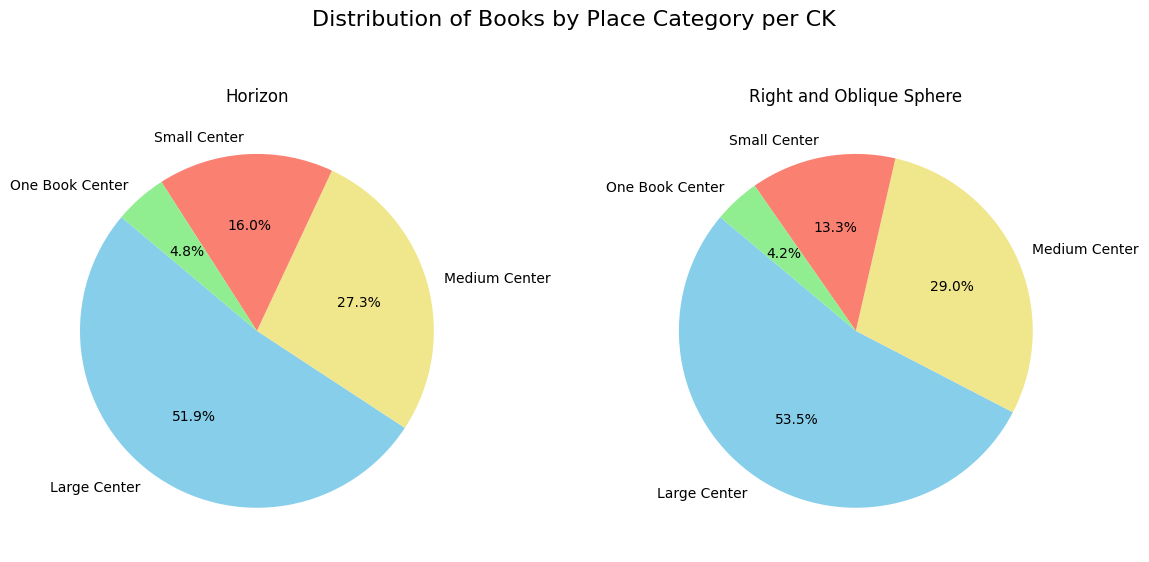

In [11]:
# === Assume filtered_df already filtered to target_cks ===

target_cks = [
'CK_Horizon', 
# 'CK_Right and Oblique Sphere', 
# 'CK_Sun Lines and Motion',
# 'CK_Geometry for Geometry', 
# 'CK_Elevation of the Pole', 
# 'CK_Equinoctial',
# 'CK_Meridian', 
# 'CK_Celestial Coordinates', 
# 'CK_Sundial',
# 'CK_Geometric Demonstrations for Instruments',
'CK_Right and Oblique Sphere'
]


# Drop duplicates per (CK, book) — this is the key line
unique_ck_books = df.drop_duplicates(subset=['cks', 'book'])

# Prepare consistent color map
place_categories = unique_ck_books['place_category'].dropna().unique().tolist()
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki', 'plum', 'orange', 'lightcoral', 'lightsteelblue']
category_color_map = {
    cat: color_palette[i % len(color_palette)] for i, cat in enumerate(place_categories)
}

# Setup plots
num_cks = len(target_cks)
fig, axes = plt.subplots(1, num_cks, figsize=(6 * num_cks, 6))
if num_cks == 1:
    axes = [axes]

# Group by CK after deduplication
grouped = unique_ck_books.groupby('cks')

# Loop through CKs and plot pies
for ax, ck in zip(axes, target_cks):
    if ck in grouped.groups:
        ck_df = grouped.get_group(ck)
        counts = ck_df.groupby('place_category')['book'].nunique().sort_values(ascending=False)
        colors = [category_color_map.get(cat, 'gray') for cat in counts.index]

        ax.pie(
            counts,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=140
        )
        ax.set_title(ck.replace('CK_', '').replace('_', ' '), fontsize=12)
    else:
        ax.set_title(f'{ck}: No Data')
        ax.axis('off')

# Final layout
plt.suptitle('Distribution of Books by Place Category per CK', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.9])
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.3_pies_place_cat.png', dpi=300)

plt.show()

Number of Unique Books per CK Group, All Books, and Filtered Books:
               CK_Horizon  CK_Right and Oblique Sphere  All Books  \
year_interval                                                       
1470-1489               2                            6         14   
1490-1509               8                           25         37   
1510-1529              12                           21         30   
1530-1549              12                           39         48   
1550-1569              55                           71         88   
1570-1589              40                           55         69   
1590-1609              38                           45         45   
1610-1629              16                           20         23   
1630-1650               4                            4          4   

               Filtered Books  
year_interval                  
1470-1489                  11  
1490-1509                  36  
1510-1529                  30  
1530-1549   

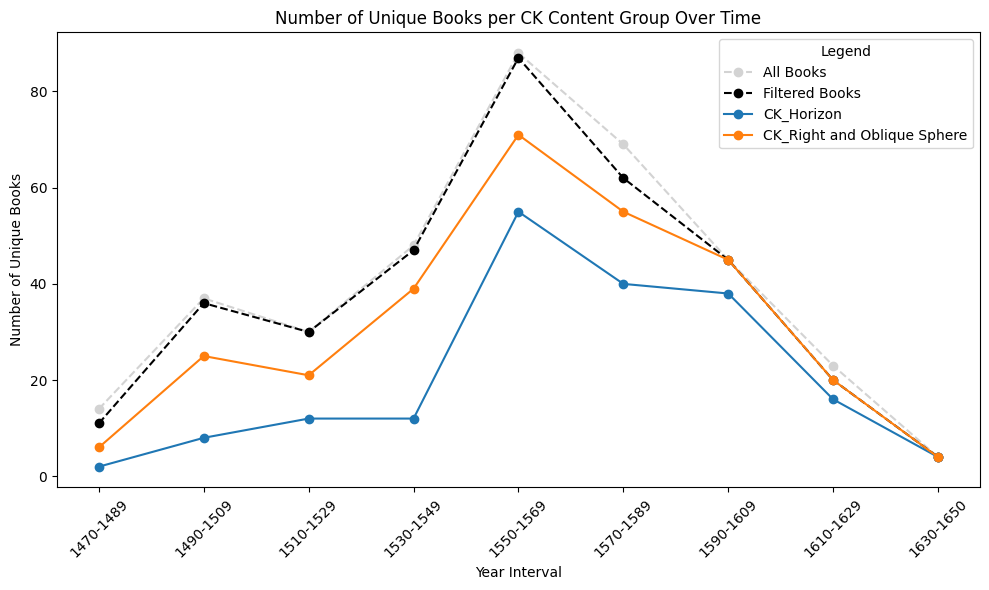

In [12]:

# Define target CK tags
target_cks = [
'CK_Horizon', 
# 'CK_Right and Oblique Sphere', 
# 'CK_Sun Lines and Motion',
# 'CK_Geometry for Geometry', 
# 'CK_Elevation of the Pole', 
# 'CK_Equinoctial',
# 'CK_Meridian', 
# 'CK_Celestial Coordinates', 
# 'CK_Sundial',
# 'CK_Geometric Demonstrations for Instruments'
'CK_Right and Oblique Sphere'
]

# ✅ 1. Total books per year_interval (from full books df)
all_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# ✅ 2. Total books per year_interval (from filtered_df)
filtered_books_count = df.groupby('year_interval', observed=False)['book'].nunique()

# ✅ Use the full timeline from all_books_count
intervals = all_books_count.index.astype(str)

# ✅ 3. Book counts per CK from filtered_df
book_counts = {
    keyword: (
        df[df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# ✅ 4. Create unified DataFrame
book_counts_df = pd.DataFrame(book_counts).reindex(all_books_count.index).fillna(0)
book_counts_df['All Books'] = all_books_count
book_counts_df['Filtered Books'] = filtered_books_count.reindex(all_books_count.index).fillna(0)

# ✅ 5. Print the summary table
print("Number of Unique Books per CK Group, All Books, and Filtered Books:")
print(book_counts_df)

# ✅ 6. Plotting
plt.figure(figsize=(10, 6))

# Plot total number of books (full dataset)
plt.plot(intervals, book_counts_df['All Books'].values, label='All Books', marker='o', color='lightgrey', linestyle='--')

# Plot number of filtered books
plt.plot(intervals, book_counts_df['Filtered Books'].values, label='Filtered Books', marker='o', color='black', linestyle='--')

# Plot each CK content group (only where values are non-zero)
for keyword in target_cks:
    values = book_counts_df[keyword].values
    non_zero_intervals = [intervals[i] for i, val in enumerate(values) if val > 0]
    non_zero_values = [val for val in values if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# ✅ 7. Final touches
plt.title('Number of Unique Books per CK Content Group Over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()

# ✅ 8. Save the figure
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.3_horizon_num_books_cks.png', dpi=300)

# ✅ 9. Show the plot
plt.show()


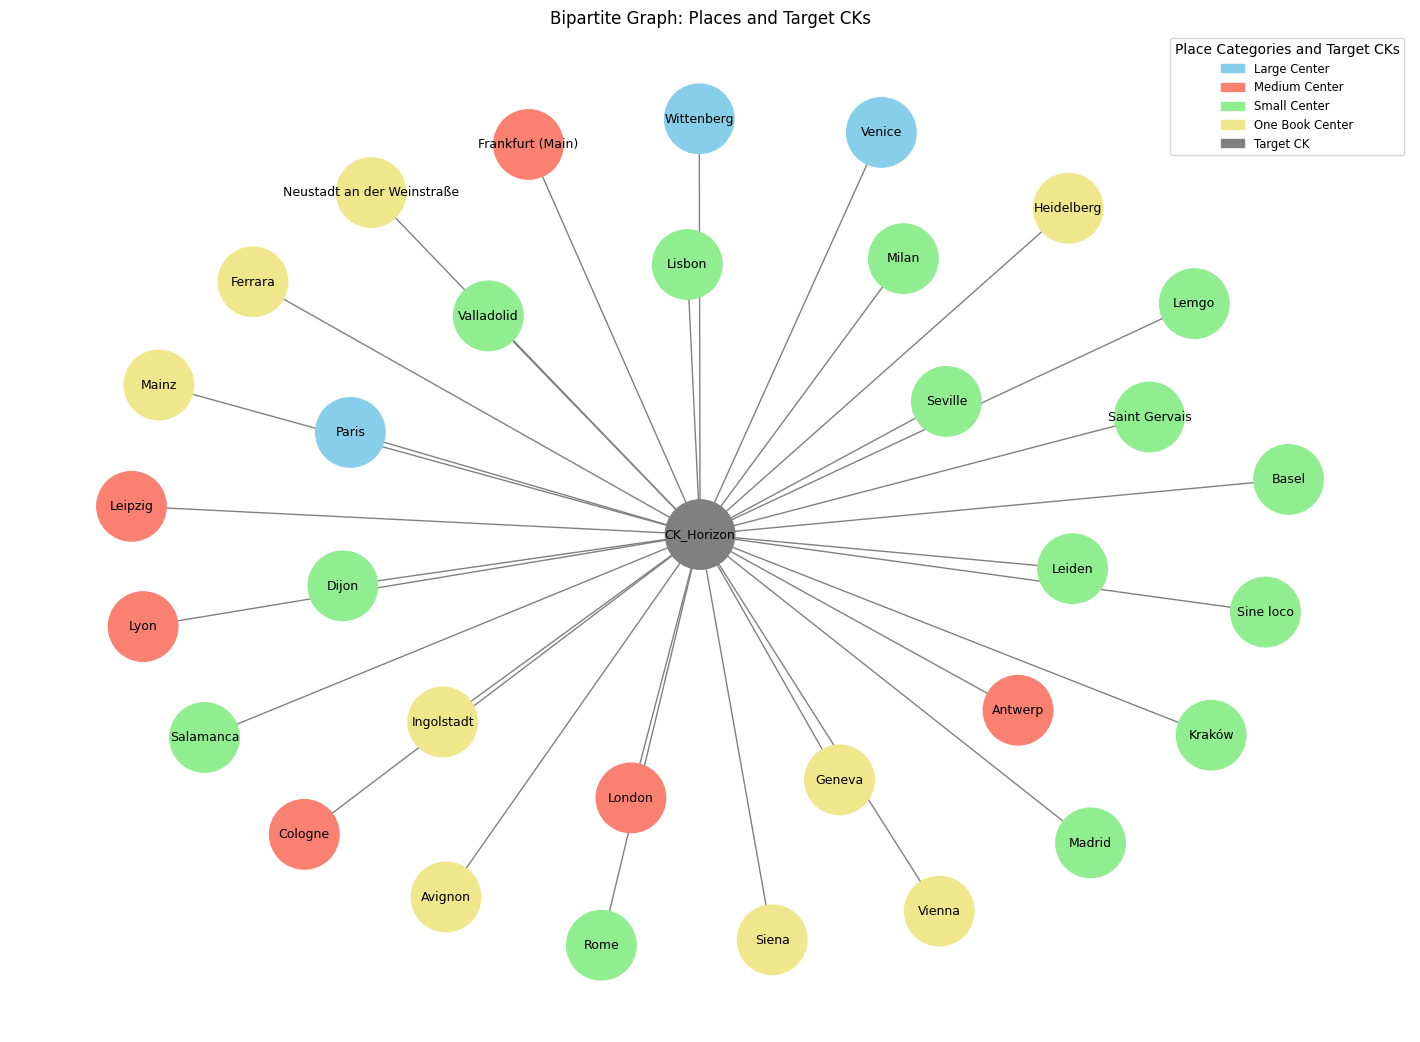

In [13]:
# target CKs list
target_cks = [
'CK_Horizon', 
# 'CK_Right and Oblique Sphere', 
# 'CK_Sun Lines and Motion',
# 'CK_Geometry for Geometry', 
# 'CK_Elevation of the Pole', 
# 'CK_Equinoctial',
# 'CK_Meridian' 'CK_Celestial Coordinates', 
# 'CK_Sundial',
# 'CK_Geometric Demonstrations for Instruments'
]

# Use filtered_df instead of visual_df
places = df['place'].dropna().unique().tolist()

edges = []

for place in places:
    place_data = df[df['place'] == place]

    # Add edges only between place and target CK if place_data contains that CK
    for cks in target_cks:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

# Unique nodes
places_nodes = list(set(edge[0] for edge in edges))
cks_nodes = list(set(edge[1] for edge in edges))

# Color palette and mapping (places by category)
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

place_color_map = {}
for place in places_nodes:
    cat_series = df[df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# Build graph
G = nx.Graph()
G.add_nodes_from(places_nodes, bipartite=0)
G.add_nodes_from(cks_nodes, bipartite=1)
G.add_edges_from(edges)

# Node colors:
node_colors = []
for node in G.nodes():
    if node in places_nodes:
        node_colors.append(place_color_map.get(node, 'gray'))
    else:
        # target CK nodes colored grey
        node_colors.append('gray')

# Draw graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.8)  # Try 0.8, 1.0, or higher

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# Legend
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='gray', label='Target CK'))

plt.legend(
    handles=legend_handles,
    title='Place Categories and Target CKs',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Places and Target CKs")

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.3_place_network.png', dpi=300)


plt.show()


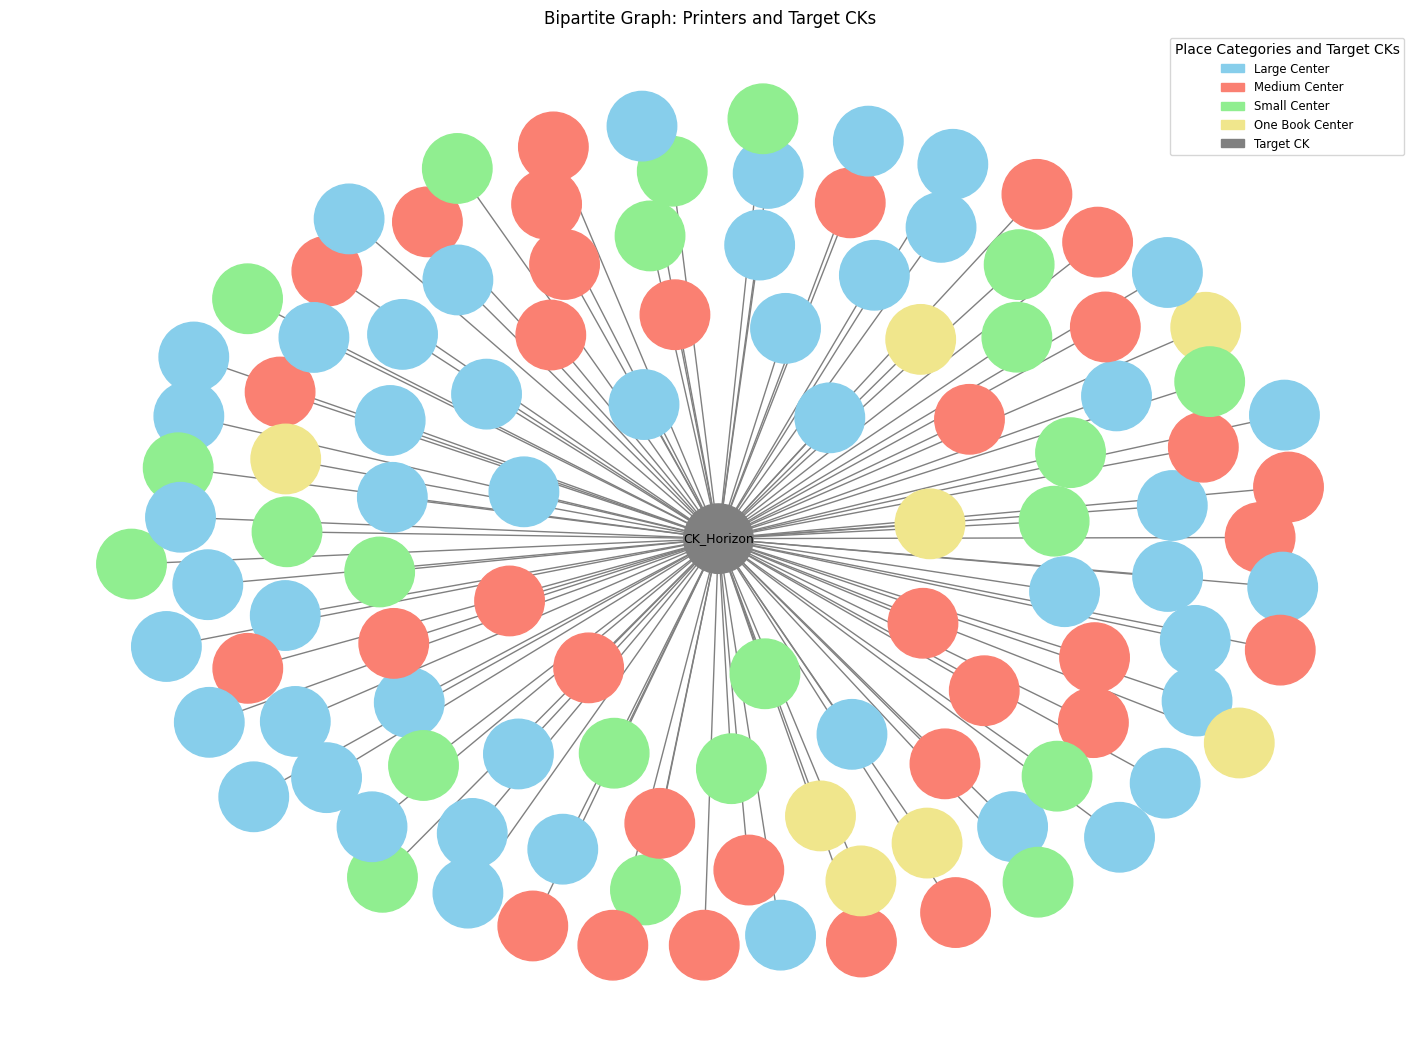

In [14]:
# target CKs list
target_cks = [
'CK_Horizon', 
# 'CK_Right and Oblique Sphere', 
# 'CK_Sun Lines and Motion',
# 'CK_Geometry for Geometry', 
# 'CK_Elevation of the Pole', 
# 'CK_Equinoctial',
# 'CK_Meridian', 
# 'CK_Celestial Coordinates', 
# 'CK_Sundial',
# 'CK_Geometric Demonstrations for Instruments'
]

# Use filtered_df instead of visual_df
printers = filtered_df['printer'].dropna().unique().tolist()

edges = []

for printer in printers:
    printer_data = filtered_df[filtered_df['printer'] == printer]

    # Add edges only between printer and target CK if printer_data contains that CK
    for cks in target_cks:
        if (printer_data['cks'] == cks).any():
            edges.append((printer, cks))

# Unique nodes
printer_nodes = list(set(edge[0] for edge in edges))
cks_nodes = list(set(edge[1] for edge in edges))

# Color palette and mapping (printers by place category)
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = filtered_df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {cat: color for cat, color in zip(ordered_present_categories, color_palette)}

printer_color_map = {}
for printer in printer_nodes:
    cat_series = filtered_df[filtered_df['printer'] == printer]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    printer_color_map[printer] = category_color_map.get(category, 'gray')

# Build graph
G = nx.Graph()
G.add_nodes_from(printer_nodes, bipartite=0)
G.add_nodes_from(cks_nodes, bipartite=1)
G.add_edges_from(edges)

# Node colors:
node_colors = []
for node in G.nodes():
    if node in printer_nodes:
        node_colors.append(printer_color_map.get(node, 'gray'))
    else:
        # target CK nodes colored grey
        node_colors.append('gray')


# First draw the graph without labels
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=False,  # ✅ No labels here
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)


# Then draw labels only for CK nodes
labels = {node: node for node in cks_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)


# Legend
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='gray', label='Target CK'))

plt.legend(
    handles=legend_handles,
    title='Place Categories and Target CKs',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Printers and Target CKs")

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.2_symbols_printers_network.png', dpi=300)


plt.show()


In [15]:
#merge visual tags with filtered_df on cluster_name
visual_df = pd.merge(filtered_df, visual_tags, on='cluster_name')
# visual_df
print(visual_df.columns)

Index(['images', 'cluster_name', 'cks', 'book', 'bid', 'part_or_adaption',
       'part_or_adaption_label', 'type_label', 'custom_identifier', 'place',
       'year', 'flag', 'year_interval', 'place_category', 'latitude',
       'longitude', 'part_type', 'printer', 'publisher', '3D', 'human figures',
       'material object (double lines)', 'multiple moments',
       'multiple perspectives', 'color', 'multiple circles',
       'decorated or stars, tail, scales', 'picture', 'terraqueous globe',
       'diagram', 'small circles representing mutual three dimensional motion',
       'symbol', '3D decoration', '3D main point', 'Unnamed: 3', '3D_geo',
       'human figures_geo', 'material representation', 'diagram_geo'],
      dtype='object')


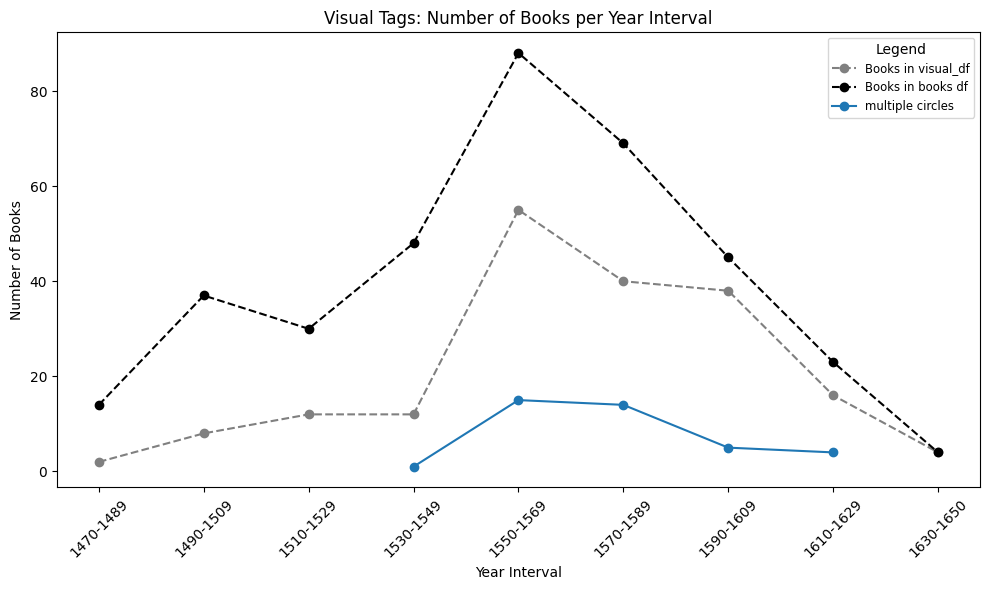

In [16]:

plt.figure(figsize=(10, 6))

# Define visual tag columns
defined_columns = [
# '3D', 
# 'human figures',
# 'material object (double lines)', 
# 'multiple moments',
# 'multiple perspectives', 
# 'color', 
# 'decorated or stars, tail, scales', 
# 'picture', 
# 'terraqueous globe',
# 'diagram', 
# 'small circles representing mutual three dimensional motion',
# 'symbol', 
# '3D decoration',
# '3D main point', 
# '3D_geo',
# 'human figures_geo', 
# 'material representation',
# 'diagram_geo',
  'multiple circles',
    ]

# Define sorted intervals
intervals = sorted(visual_df['year_interval'].dropna().unique())

# 1. Total unique books per interval in visual_df
unique_books_visual = (
    visual_df.groupby('year_interval', observed=False)['book']
    .nunique()
    .reindex(intervals, fill_value=0)
)

# 2. Total unique books per interval in books df
unique_books_from_books_df = (
    books.groupby('year_interval', observed=False)['book']
    .nunique()
    .reindex(intervals, fill_value=0)
)

# Plot total lines
plt.plot(intervals, unique_books_visual.values, label='Books in visual_df', marker='o', color='grey', linestyle='--')
plt.plot(intervals, unique_books_from_books_df.values, label='Books in books df', marker='o', color='black', linestyle='--')

# 3. Plot each visual tag with zero-excluding logic
for col in defined_columns:
    books_with_tag = (
        visual_df[visual_df[col] == 'yes']
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .reindex(intervals, fill_value=0)
    )

    # Filter out intervals with zero values
    non_zero_intervals = [interval for interval, val in zip(intervals, books_with_tag.values) if val > 0]
    non_zero_values = [val for val in books_with_tag.values if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=col)

# Final formatting
plt.title('Visual Tags: Number of Books per Year Interval')
plt.xlabel('Year Interval')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.legend(title='Legend', fontsize='small', title_fontsize='medium')
plt.tight_layout()

# Save and show
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.3_horizon_visual_lines.png', dpi=300)
plt.show()


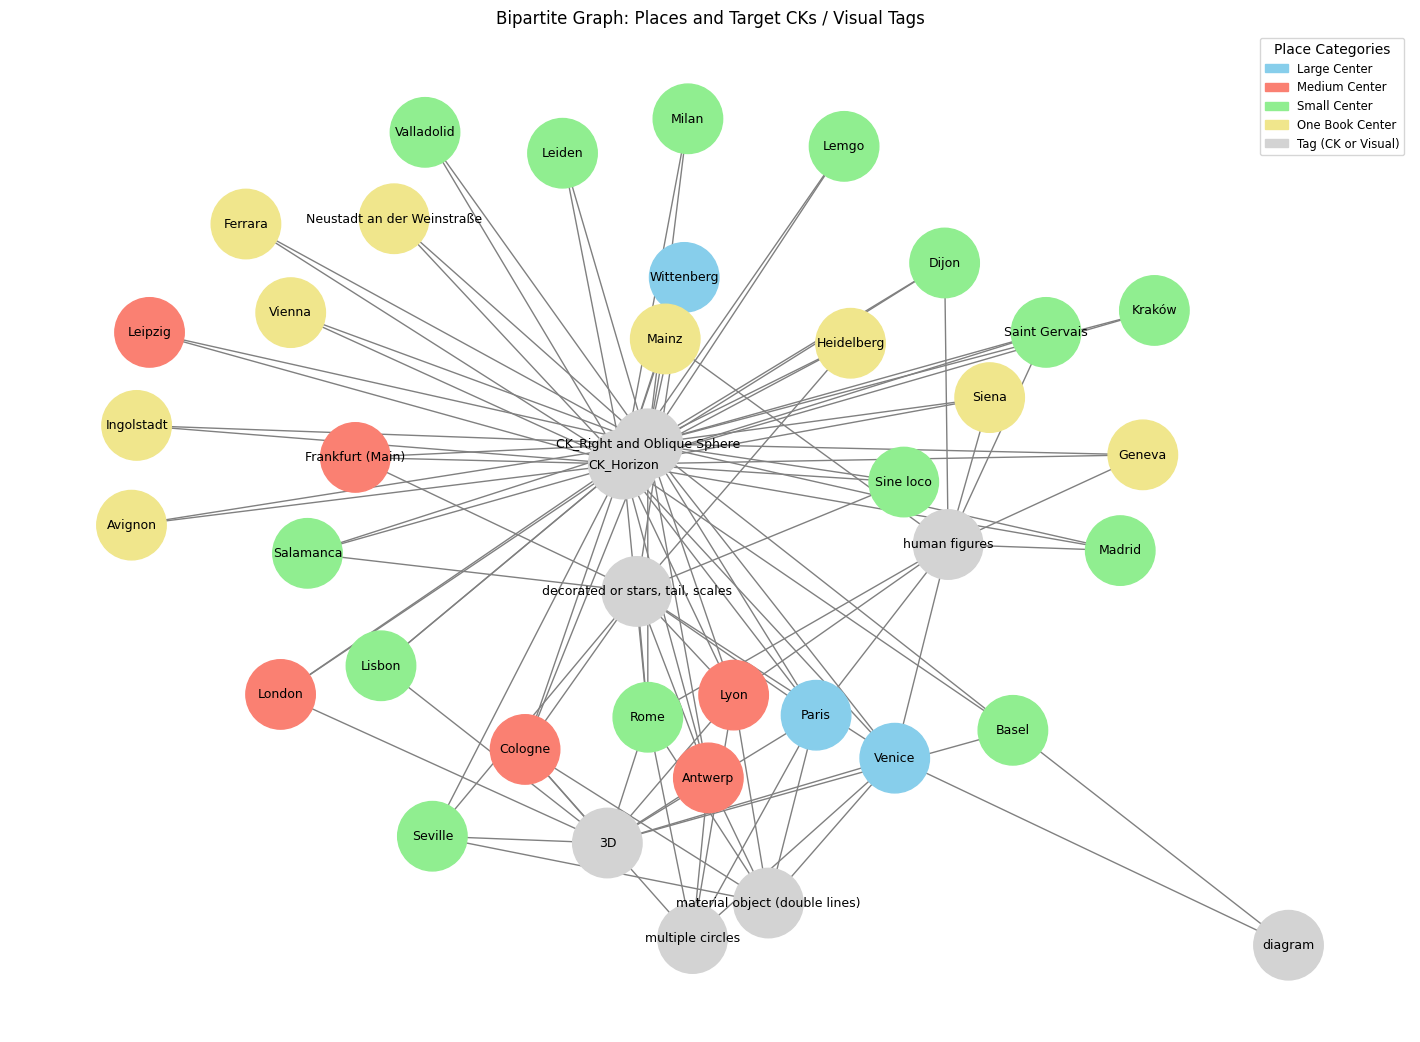

In [17]:

# === Assumes this is already defined earlier ===
target_cks = [
# 'CK_Meridian',
'CK_Horizon',
# 'CK_Elevation of the Pole',
'CK_Right and Oblique Sphere'
]

# === Step 1: Visual tags ===
defined_columns = [
'3D', 
'human figures',
'material object (double lines)', 
# 'multiple moments',
# 'multiple perspectives', 
# 'color', 
'multiple circles',
'decorated or stars, tail, scales', 
# # 'picture', 
# 'terraqueous globe',
'diagram', 
# # 'small circles representing mutual three dimensional motion',
# # 'symbol', 
# '3D decoration',
# '3D main point', 
# # '3D_geo',
# # 'human figures_geo', 
# # 'material representation',
# 'diagram_geo'

]

# === Step 2: Build edge list ===
edges = []
places = visual_df['place'].dropna().unique().tolist()

for place in places:
    place_data = visual_df[visual_df['place'] == place]

    # Add CKs only if in target_cks
    for cks in target_cks:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

    # Add visual tag edges
    for tag in defined_columns:
        if (place_data[tag] == 'yes').any():
            edges.append((place, tag))

# Optional: inspect edge structure
# edges_df = pd.DataFrame(edges, columns=['place', 'tag'])
# print(edges_df)

# === Step 3: Unique node sets ===
places = list(set(edge[0] for edge in edges))
tags = list(set(edge[1] for edge in edges))

# === Step 4: Color by place category ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
existing_categories = visual_df['place_category'].dropna().unique()
ordered_present_categories = [cat for cat in ordered_categories if cat in existing_categories]

color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {
    cat: color for cat, color in zip(ordered_present_categories, color_palette)
}

place_color_map = {}
for place in places:
    cat_series = visual_df[visual_df['place'] == place]['place_category'].dropna()
    category = cat_series.iloc[0] if not cat_series.empty else 'unknown'
    place_color_map[place] = category_color_map.get(category, 'gray')

# === Step 5: Build the graph ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(tags, bipartite=1)
G.add_edges_from(edges)

# === Step 6: Assign node colors ===
node_colors = [
    place_color_map[node] if node in places else 'lightgray'
    for node in G.nodes()
]

# === Step 7: Draw ===
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# === Step 8: Legend ===
legend_handles = [
    mpatches.Patch(color=category_color_map[cat], label=cat)
    for cat in ordered_present_categories
]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (CK or Visual)'))

plt.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)
plt.title("Bipartite Graph: Places and Target CKs / Visual Tags")

# === Step 9: Save or show ===
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/2.3_horizon_visual_network.png', dpi=300)
plt.show()
